In [2]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 7.1 MB/s eta 0:00:00



Best Solution: [2, 4, 11, 14, 9, 4, 8, 12, 13, 4]
Final Service Time: 0.2706 seconds


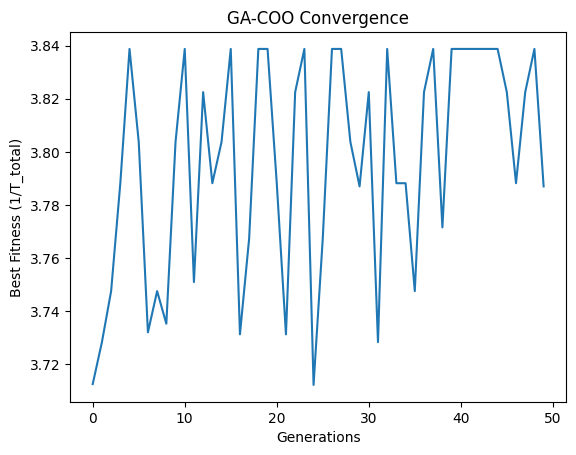

In [17]:
"""
GA-COO: Genetic Algorithm for Computation Offloading Optimization in MEC
Based on: Myyara et al., IJ-AI Vol.13(4), 2024
"""

import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# ===============================
# PARAMETERS (Paper-based)
# ===============================

POP_SIZE = 100
GEN = 50
CX_PB = 0.8
MUT_PB = 0.2
TOURN_SIZE = 3

NUM_TASKS = 10          # Can scale to 100–2300
NUM_MEC = 14
NUM_SERVERS = 15        # 14 MEC + 1 Cloud
CLOUD_INDEX = 15        # 0=Local, 1-14=MEC, 15=Cloud

# Task parameters
TASK_LENGTHS = np.random.randint(10**7, 10**8, NUM_TASKS)
DATA_SIZE = 1  # MB

F_LOCAL = 0.3e9
F_MEC = 10e9
F_CLOUD = 50e9


DELAYS = {
    'up_mec': 0.01,
    'dw_mec': 0.01,
    'up_cloud': 0.3,
    'dw_cloud': 0.2
}

DS = np.random.uniform(0.2, 0.8, NUM_TASKS)
VM_CAPACITY = 0.8


# ===============================
# SAFE CLASS CREATION
# ===============================

if "FitnessMax" not in creator.__dict__:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register("attr_server", random.randint, 0, CLOUD_INDEX)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_server, n=NUM_TASKS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# ===============================
# FITNESS FUNCTION
# ===============================

def calculate_service_time(individual):
    total_time = 0
    vm_loads = np.zeros(NUM_SERVERS)

    for i, server in enumerate(individual):
        task_length = TASK_LENGTHS[i]
        ds = DS[i]

        if server == 0:
            t_proc = task_length / F_LOCAL
            total_time += t_proc
        else:
            if server <= NUM_MEC:
                t_trans = DATA_SIZE * (DELAYS['up_mec'] + DELAYS['dw_mec'])
                t_proc = task_length / F_MEC
                vm_index = server - 1
            else:
                t_trans = DATA_SIZE * (DELAYS['up_cloud'] + DELAYS['dw_cloud'])
                t_proc = task_length / F_CLOUD
                vm_index = NUM_SERVERS - 1

            total_time += t_trans + t_proc
            vm_loads[vm_index] += t_proc

        # Delay sensitivity penalty
        if random.random() > ds:
            total_time *= 1.05

    # Capacity penalty
    if np.any(vm_loads > VM_CAPACITY):
        total_time *= 5

    return (1 / total_time,)


toolbox.register("evaluate", calculate_service_time)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt,
                 low=[0]*NUM_TASKS,
                 up=[CLOUD_INDEX]*NUM_TASKS,
                 indpb=0.1)
toolbox.register("select", tools.selTournament,
                 tournsize=TOURN_SIZE)


# ===============================
# GREEDY REFINEMENT
# ===============================

def greedy_refinement(individual):
    vm_loads = np.zeros(NUM_SERVERS)

    for i, server in enumerate(individual):
        if server > 0:
            idx = server - 1 if server <= NUM_MEC else NUM_SERVERS - 1
            vm_loads[idx] += TASK_LENGTHS[i] / F_MEC

    for i, server in enumerate(individual):
        if server > 0:
            idx = server - 1 if server <= NUM_MEC else NUM_SERVERS - 1
            if vm_loads[idx] > VM_CAPACITY:
                underloaded = np.where(vm_loads < VM_CAPACITY / 2)[0]
                if len(underloaded) > 0:
                    new_server = underloaded[0] + 1
                    individual[i] = new_server

    return individual


# ===============================
# MAIN GA EXECUTION
# ===============================

def run_ga_coo():
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max)

    logbook = tools.Logbook()

    for gen in range(GEN):
        offspring = algorithms.varAnd(pop, toolbox, cxpb=CX_PB, mutpb=MUT_PB)
        fits = list(map(toolbox.evaluate, offspring))

        for ind, fit in zip(offspring, fits):
            ind.fitness.values = fit

        pop = toolbox.select(offspring, k=len(pop))
        hof.update(pop)

        record = stats.compile(pop)
        logbook.record(gen=gen, **record)

    best = hof[0]
    best = greedy_refinement(best)
    final_time = 1 / calculate_service_time(best)[0]

    print("\nBest Solution:", best)
    print("Final Service Time:", round(final_time, 4), "seconds")

    return logbook


# ===============================
# RUN + PLOT
# ===============================

log = run_ga_coo()

generations = log.select("gen")
fitness_values = log.select("max")

plt.figure()
plt.plot(generations, fitness_values)
plt.xlabel("Generations")
plt.ylabel("Best Fitness (1/T_total)")
plt.title("GA-COO Convergence")
plt.show()